MOHAMMED ALTOWAIRQI-2240005295

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, exposure, img_as_float

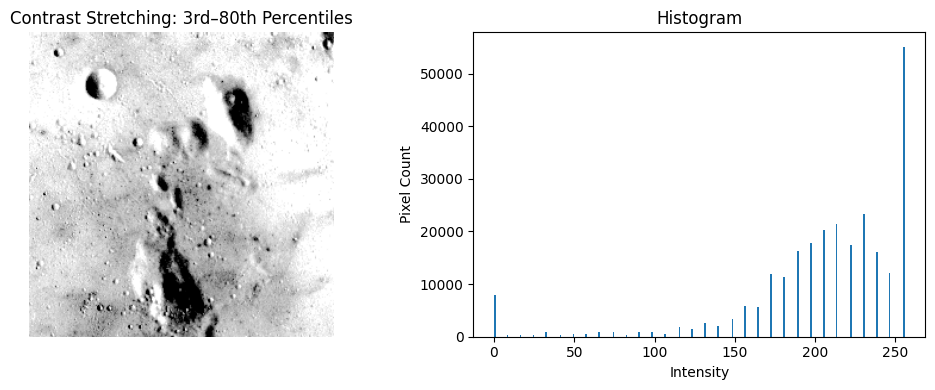

In [5]:
# Task 1: Contrast stretching using the 3rd and 80th percentiles
moon = data.moon()
p3, p80 = np.percentile(moon, (3, 80))
stretched = exposure.rescale_intensity(moon, in_range=(p3, p80))
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(stretched, cmap="gray", vmin=0, vmax=255)
axes[0].set_title("Contrast Stretching: 3rd–80th Percentiles")
axes[0].axis("off")
axes[1].hist(stretched.ravel(), bins=256, range=(0, 256))
axes[1].set(title="Histogram", xlabel="Intensity", ylabel="Pixel Count")
plt.tight_layout()
plt.show()

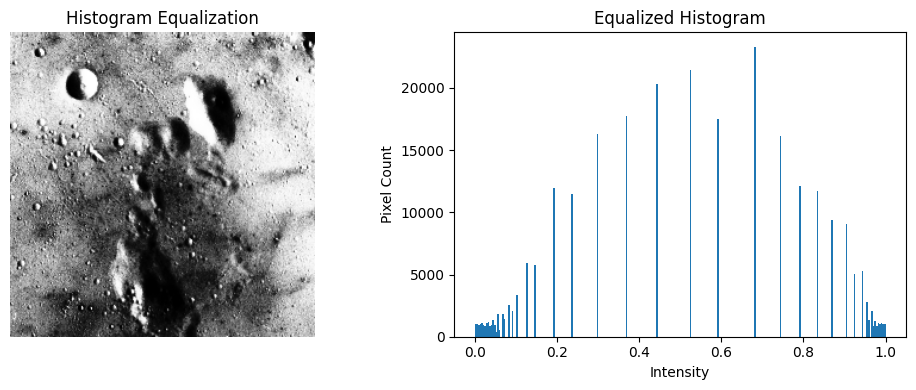

In [6]:

# Task 2: Histogram equalization
equalized = exposure.equalize_hist(moon)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(equalized, cmap="gray", vmin=0, vmax=1)
axes[0].set_title("Histogram Equalization")
axes[0].axis("off")
axes[1].hist(equalized.ravel(), bins=256, range=(0, 1))
axes[1].set(title="Equalized Histogram", xlabel="Intensity", ylabel="Pixel Count")
plt.tight_layout()
plt.show()

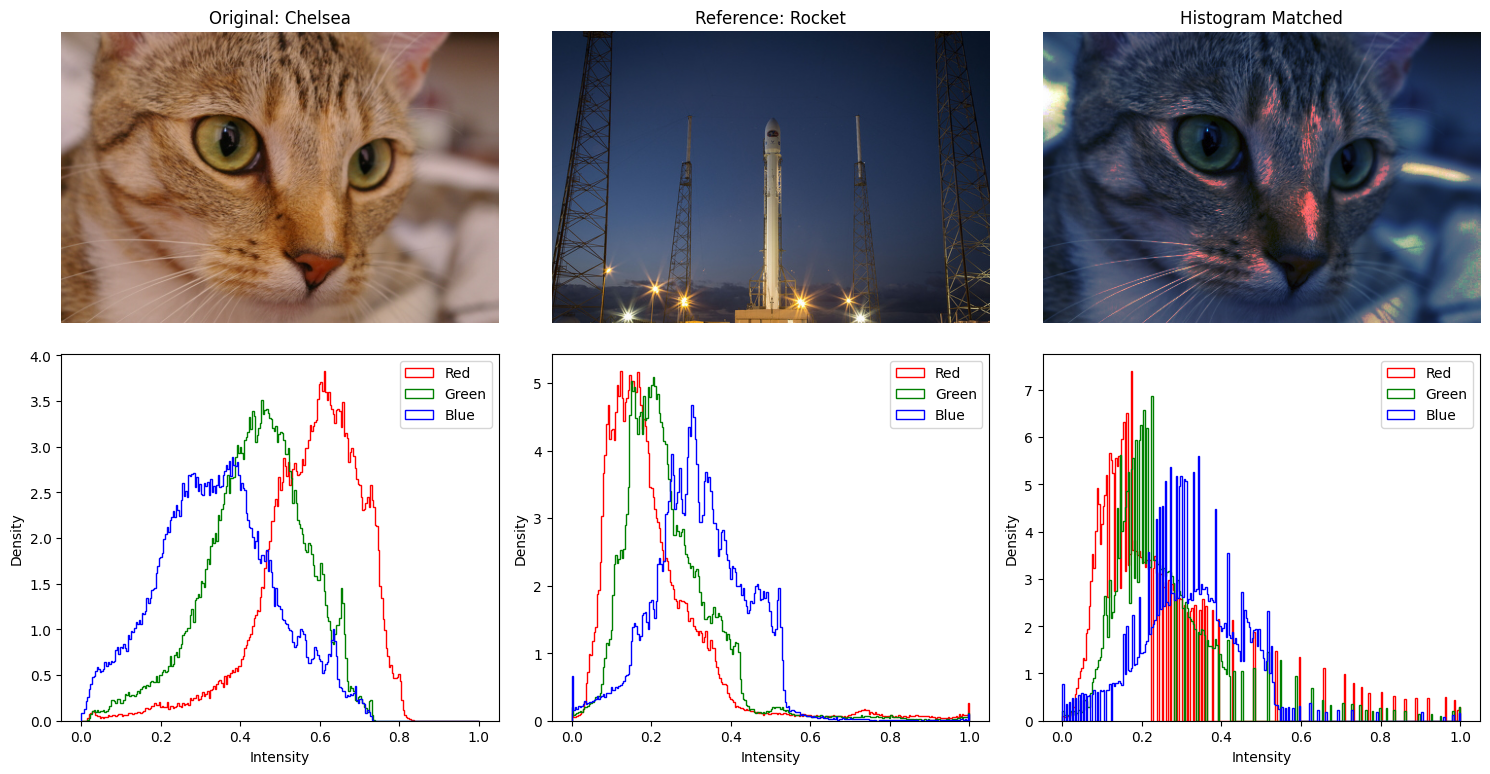

In [7]:
# Task 3: Match Chelsea's histogram to the rocket reference
chelsea = img_as_float(data.chelsea())
rocket = img_as_float(data.rocket())
matched = exposure.match_histograms(chelsea, rocket, channel_axis=-1)

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
images = [chelsea, rocket, matched]
titles = ["Original: Chelsea", "Reference: Rocket", "Histogram Matched"]

for column, (image, title) in enumerate(zip(images, titles)):
    axes[0, column].imshow(image)
    axes[0, column].set_title(title)
    axes[0, column].axis("off")

    for channel, color in enumerate(["red", "green", "blue"]):
        axes[1, column].hist(
            image[..., channel].ravel(),
            bins=256,
            range=(0, 1),
            density=True,
            histtype="step",
            color=color,
            label=color.capitalize()
        )

    axes[1, column].set(xlabel="Intensity", ylabel="Density")
    axes[1, column].legend()

plt.tight_layout()
plt.show()